# 🚀 통합 조건부 오토인코더(CAE) - 성능 최적화 버전

이 노트북은 **실제 PostgreSQL DB 벡터 데이터**를 사용하여 **이종 벡터 통합 압축**을 수행하는 **완전 최적화된 파이프라인**입니다.

### 🎯 핵심 개선사항
- **✅ 동적 컬럼 감지**: 각 테이블별 다른 파라미터 구조 자동 처리
- **✅ 데이터 타입 통일**: categorical/numerical 컬럼의 혼재 타입 문제 해결
- **✅ 견고한 전처리**: 복잡한 타입(list, dict) 자동 제외 및 안전한 변환
- **✅ 완전 자동 훈련**: 체크포인트 감지 및 자동 재시작 지원
- **⚡ 성능 최적화**: 벡터화된 복합 손실 함수로 극적인 속도 향상

### 📊 데이터 규모 조절 방법

**Cell 5 (메인 실행 파이프라인)**에서 `data_limit` 값을 변경하여 사용할 데이터 양을 조절할 수 있습니다:

```python
# 메모리 절약을 위한 데이터 제한 (필요에 따라 조정)
data_limit = 100000  # ← 이 값을 변경하세요
```

#### 🔧 권장 설정표

| 목적 | `data_limit` | 추가 권장 설정 (Cell 2 - TrainingConfig) |
|------|-------------|----------------------------------------|
| **빠른 테스트** | `10,000` | 기본 설정 그대로 |
| **중간 실험** | `100,000` | 기본 설정 그대로 |
| **대규모 실험** | `500,000` | `batch_size=64`, `num_epochs=15` |
| **전체 데이터** | `None` | `batch_size=32`, `num_epochs=10`, `validation_split=0.02` |

#### ⚠️ 메모리 주의사항
- 전체 데이터(157만개): 약 222GB 메모리 필요 → 배치 처리로 최적화됨
- 시스템 메모리에 따라 `data_limit`을 조절하세요
- 메모리 부족 시 더 작은 값부터 시작하여 점진적으로 증가

### 💡 사용법
순서대로 모든 셀을 실행하면 됩니다. (`Run All` 또는 순차 실행)

# 🚀 통합 조건부 오토인코더(CAE) - 데이터 타입 문제 해결 버전

이 노트북은 **실제 PostgreSQL DB 벡터 데이터**를 사용하여 **이종 벡터 통합 압축**을 수행하는 **완전 최적화된 파이프라인**입니다.

### 🎯 핵심 개선사항
- **✅ 동적 컬럼 감지**: 각 테이블별 다른 파라미터 구조 자동 처리
- **✅ 데이터 타입 통일**: categorical/numerical 컬럼의 혼재 타입 문제 해결
- **✅ 견고한 전처리**: 복잡한 타입(list, dict) 자동 제외 및 안전한 변환
- **✅ 완전 자동 훈련**: 체크포인트 감지 및 자동 재시작 지원
- **🆕 복합 Loss 함수**: MSE + 코사인 유사도 결합으로 더 나은 복원 성능

### ⚡ 성능 최적화 핵심 개선사항

**1. 벡터화된 복합 손실 함수**
- 기존: 배치 내 각 샘플마다 순차 루프 (O(batch_size))
- 개선: GPU 병렬 벡터화 연산 (O(1))
- **결과**: 약 10-50배 속도 향상

**2. 최적화된 하이퍼파라미터**
- `batch_size: 256` (128 → 256): 더 큰 배치로 GPU 활용 극대화
- `learning_rate: 2e-3` (1e-3 → 2e-3): 빠른 수렴
- `num_epochs: 30` (50 → 30): 효율적인 훈련

### 🧮 복합 Loss 함수 

**공식**: `total_loss = α * MSE + β * (1 - cosine_similarity)`

**Cell 5 (TrainingConfig)**에서 복합 loss 함수 파라미터 조정:

```python
# 복합 Loss 함수 설정
use_composite_loss: bool = True  # 복합 loss 사용 여부
mse_weight: float = 1.0         # α: MSE 가중치
cosine_weight: float = 0.5      # β: 코사인 유사도 가중치
```

#### 📊 Loss 가중치 조절 가이드

| 목적 | `mse_weight` | `cosine_weight` | 설명 |
|------|-------------|----------------|------|
| **정확한 복원** | `1.0` | `0.1` | MSE 중심, 점별 정확도 최우선 |
| **균형잡힌 학습** | `1.0` | `0.5` | **기본 권장 설정** |
| **방향성 중시** | `0.7` | `1.0` | 코사인 유사도 중심, 벡터 방향 보존 |
| **순수 MSE** | `1.0` | `0.0` | 기존 MSE만 사용 |

### 💡 사용법
순서대로 모든 셀을 실행하면 됩니다. (`Run All` 또는 순차 실행)


## 1. 라이브러리 임포트 및 환경 설정


In [1]:
import os
import sys
import logging
import pickle
import time
import shutil
from datetime import datetime
from pathlib import Path
from dataclasses import dataclass, field
from typing import Dict, List, Tuple, Optional, Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split

from sqlalchemy import create_engine
from sklearn.preprocessing import OneHotEncoder, StandardScaler



# --- 기본 설정 ---
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

def set_seed(seed=42):
    """재현성을 위한 시드 고정"""
    import random
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = False
        torch.backends.cudnn.benchmark = True

set_seed(42)
logging.info("✅ 라이브러리 로드 및 기본 설정 완료")


2025-06-22 23:10:50,826 - INFO - ✅ 라이브러리 로드 및 기본 설정 완료


## 2. 설정 관리 (`TrainingConfig`)


In [2]:
@dataclass
class TrainingConfig:
    """훈련에 필요한 모든 설정을 통합 관리하는 클래스"""
    # --- DB 설정 ---
    db_user: str = 'postgres'
    db_password: str = 'postgres'
    db_host: str = 'localhost'
    db_port: int = 5432
    db_name: str = 'postgres'

    # --- 모델 아키텍처 ---
    input_dim: int = 512       # 데이터 로드 후 자동으로 업데이트됨
    condition_dim: int = 30    # 데이터 로드 후 자동으로 업데이트됨
    latent_dim: int = 64
    hidden_dims: List[int] = field(default_factory=lambda: [256, 128])

    # --- 훈련 하이퍼파라미터 (최적화된 설정) ---
    # 테스트용 변수들
    
    # batch_size: int = 256  # 복합 손실 최적화로 더 큰 배치 가능
    # num_epochs: int = 50   # 빠른 수렴으로 에포크 수 줄임
    # learning_rate: float = 2e-3  # 더 빠른 학습률로 수렴 가속
    # validation_split: float = 0.05  # 메모리 절약을 위해 검증 데이터 비율 줄임
    
    
    
    # 전체 데이터용 변수들
    batch_size: int = 256  # 복합 손실 최적화로 더 큰 배치 가능
    num_epochs: int = 50   # 빠른 수렴으로 에포크 수 줄임
    learning_rate: float = 0.002  # 더 빠른 학습률로 수렴 가속 (2e-3을 실수 단위로 표현)
    validation_split: float = 0.02  # 메모리 절약을 위해 검증 데이터 비율 줄임

    
    # 이전 설정 (참고용)
    # batch_size: int = 128  # 메모리 절약을 위해 작게 설정
    # num_epochs: int = 50   # 대용량 데이터이므로 에포크 수 줄임
    # learning_rate: float = 1e-3


    

    # 메모리 절약을 위한 데이터 제한 (필요에 따라 조정)
    # data_limit = 100000  # 10만개로 제한 (전체 157만개 → 10만개)
    data_limit = None  # 10만개로 제한 (전체 157만개 → 10만개)
    
    # --- Early Stopping 및 스케줄러 ---
    patience: int = 5
    lr_scheduler_factor: float = 0.5
    lr_scheduler_patience: int = 3

    # --- 시스템 및 GPU 설정 ---
    device: str = "cuda" if torch.cuda.is_available() else "cpu"
    num_workers: int = 0  # Windows 안정성을 위해 0, 필요시 2 또는 4로 조정
    pin_memory: bool = True if torch.cuda.is_available() else False

    # --- 저장 경로 ---
    checkpoint_dir: str = "checkpoints"
    
    # --- 복합 Loss 함수 설정 ---
    use_composite_loss: bool = True  # 복합 loss 사용 여부
    mse_weight: float = 1.0  # α: MSE 가중치
    cosine_weight: float = 0.5  # β: 코사인 유사도 가중치
    
    def __post_init__(self):
        Path(self.checkpoint_dir).mkdir(parents=True, exist_ok=True)

config = TrainingConfig()
logging.info(f"✅ 설정 관리 시스템 초기화 완료. Device: {config.device}")


2025-06-22 23:10:50,862 - INFO - ✅ 설정 관리 시스템 초기화 완료. Device: cuda


In [3]:
class DatabaseManager:
    """효율적인 데이터 로딩을 위한 데이터베이스 관리 클래스"""
    def __init__(self, config: TrainingConfig):
        self.db_url = f"postgresql://{config.db_user}:{config.db_password}@{config.db_host}:{config.db_port}/{config.db_name}"
        self.engine = create_engine(self.db_url)
        logging.info("✅ 데이터베이스 엔진 생성 완료")

    def load_unified_data(self, limit=None) -> pd.DataFrame:
        """UNION ALL 쿼리를 사용하여 모든 벡터를 한 번에 효율적으로 로드"""
        logging.info(f"🔥 통합 데이터 로딩 시작... (UNION ALL 쿼리 사용, limit={limit})")
        
        # 메모리 절약을 위한 제한 옵션
        limit_clause = f" LIMIT {limit}" if limit else ""
        
        query = f"""
        SELECT 'origin' as vector_type, id, embedding::text, parameters FROM origin_vector
        UNION ALL
        SELECT 'dct' as vector_type, id, embedding::text, parameters FROM dct_vector
        UNION ALL
        SELECT 'wavelet' as vector_type, id, embedding::text, parameters FROM wavelet_vector
        {limit_clause};
        """
        try:
            start_time = time.time()
            df = pd.read_sql(query, self.engine)
            end_time = time.time()
            logging.info(f"✅ DB에서 {len(df):,}개의 데이터 로드 완료 ({end_time - start_time:.2f}초)")
            
            if len(df) > 500000:
                logging.warning(f"⚠️ 대용량 데이터 감지: {len(df):,}개. 메모리 부족 위험!")
                
            return df
        except Exception as e:
            logging.error(f"❌ 데이터 로드 실패: {e}")
            raise

class ConditionEncoder:
    """메모리 효율적인 조건 벡터 인코더 - 대용량 데이터 처리 최적화"""
    def __init__(self, max_categories_per_col=20, batch_size=50000):
        self.ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=True)  # 희소 행렬 사용
        self.scaler = StandardScaler()
        self.fitted = False
        self.categorical_cols = []
        self.numerical_cols = []
        self.max_categories_per_col = max_categories_per_col
        self.batch_size = batch_size

    def _detect_column_types(self, params_df: pd.DataFrame):
        """데이터프레임에서 categorical과 numerical 컬럼을 자동 감지 + 차원 축소"""
        categorical_cols = []
        numerical_cols = []
        
        for col in params_df.columns:
            # null이 아닌 값들 확인
            non_null_values = params_df[col].dropna()
            if len(non_null_values) == 0:
                continue
                
            # 모든 값의 타입 확인
            value_types = set(type(x).__name__ for x in non_null_values)
            
            # 리스트나 복잡한 타입은 제외
            if any(t in ['list', 'dict', 'tuple'] for t in value_types):
                logging.warning(f"⚠️ 컬럼 '{col}'은 복잡한 타입({value_types})이므로 제외됩니다.")
                continue
            
            # 숫자형 타입인지 확인
            if any(t in ['int', 'float', 'int64', 'float64', 'int32', 'float32'] for t in value_types):
                numerical_cols.append(col)
            else:
                # categorical 컬럼의 고유값 개수 확인
                unique_count = non_null_values.nunique()
                if unique_count <= self.max_categories_per_col:
                    categorical_cols.append(col)
                    logging.info(f"📊 '{col}' 컬럼: {unique_count}개 카테고리 (포함)")
                else:
                    logging.warning(f"⚠️ '{col}' 컬럼: {unique_count}개 카테고리로 너무 많아 제외됩니다.")
                
        logging.info(f"🔍 감지된 컬럼 타입: categorical={categorical_cols}, numerical={numerical_cols}")
        return categorical_cols, numerical_cols

    def fit(self, params_df: pd.DataFrame):
        logging.info("🔧 메모리 효율적 조건 인코더 fitting 시작...")
        
        # 컬럼 타입 자동 감지 (차원 축소 포함)
        self.categorical_cols, self.numerical_cols = self._detect_column_types(params_df)
        
        # 샘플링을 통한 fitting (전체 데이터 대신 샘플만 사용)
        sample_size = min(10000, len(params_df))
        sample_df = params_df.sample(n=sample_size, random_state=42)
        processed_df = sample_df.copy()
        
        # categorical 컬럼들을 모두 문자열로 변환
        for col in self.categorical_cols:
            if col in processed_df.columns:
                processed_df[col] = processed_df[col].astype(str).fillna('unknown')
        
        # numerical 컬럼들을 float로 변환
        for col in self.numerical_cols:
            if col in processed_df.columns:
                processed_df[col] = pd.to_numeric(processed_df[col], errors='coerce').fillna(0.0)
        
        # 인코더 fitting
        if self.categorical_cols:
            self.ohe.fit(processed_df[self.categorical_cols])
            # OneHot 인코딩 차원 확인
            n_features = sum(len(self.ohe.categories_[i]) for i in range(len(self.categorical_cols)))
            logging.info(f"📊 OneHot 인코딩 차원: {n_features}")
            
            if n_features > 1000:
                logging.warning(f"⚠️ OneHot 차원이 {n_features}로 매우 큽니다. 메모리 부족 위험!")
                
        if self.numerical_cols:
            self.scaler.fit(processed_df[self.numerical_cols])
            
        self.fitted = True
        logging.info(f"✅ 조건 인코더 fitting 완료. categorical: {len(self.categorical_cols)}, numerical: {len(self.numerical_cols)}")
        
    def transform_batch(self, params_df: pd.DataFrame) -> np.ndarray:
        """배치 단위로 변환하여 메모리 효율성 확보"""
        if not self.fitted:
            raise RuntimeError("Encoder has not been fitted yet.")
            
        n_samples = len(params_df)
        if n_samples <= self.batch_size:
            return self._transform_single_batch(params_df)
        
        # 대용량 데이터의 경우 배치 처리
        logging.info(f"🔄 대용량 데이터 배치 처리 시작: {n_samples:,}개 → {self.batch_size:,}개씩 처리")
        
        all_results = []
        n_batches = (n_samples + self.batch_size - 1) // self.batch_size
        
        for i in range(n_batches):
            start_idx = i * self.batch_size
            end_idx = min((i + 1) * self.batch_size, n_samples)
            batch_df = params_df.iloc[start_idx:end_idx]
            
            batch_result = self._transform_single_batch(batch_df)
            all_results.append(batch_result)
            
            if (i + 1) % 10 == 0:
                logging.info(f"📊 배치 처리 진행: {i+1}/{n_batches} ({(i+1)/n_batches*100:.1f}%)")
        
        logging.info("✅ 배치 처리 완료, 결과 결합 중...")
        final_result = np.vstack(all_results)
        logging.info(f"✅ 최종 조건 벡터 생성 완료: {final_result.shape}")
        return final_result
    
    def _transform_single_batch(self, params_df: pd.DataFrame) -> np.ndarray:
        """단일 배치 변환"""
        # 동일한 전처리 적용
        processed_df = params_df.copy()
        
        # categorical 컬럼들 처리
        for col in self.categorical_cols:
            if col in processed_df.columns:
                processed_df[col] = processed_df[col].astype(str).fillna('unknown')
        
        # numerical 컬럼들 처리
        for col in self.numerical_cols:
            if col in processed_df.columns:
                processed_df[col] = pd.to_numeric(processed_df[col], errors='coerce').fillna(0.0)
        
        # 변환 수행
        result_vectors = []
        
        if self.categorical_cols:
            cat_sparse = self.ohe.transform(processed_df[self.categorical_cols])
            cat_vec = cat_sparse.toarray().astype(np.float32)  # 희소 행렬을 dense로 변환
            result_vectors.append(cat_vec)
            
        if self.numerical_cols:
            num_vec = self.scaler.transform(processed_df[self.numerical_cols]).astype(np.float32)
            result_vectors.append(num_vec)
        
        # 결과 결합
        if result_vectors:
            return np.concatenate(result_vectors, axis=1)
        else:
            # 처리할 컬럼이 없는 경우 더미 벡터 반환
            logging.warning("⚠️ 처리할 수 있는 컬럼이 없어 더미 벡터를 반환합니다.")
            return np.zeros((len(processed_df), 1), dtype=np.float32)
    
    def transform(self, params_df: pd.DataFrame) -> np.ndarray:
        """기본 transform 메서드 (배치 처리로 리다이렉트)"""
        return self.transform_batch(params_df)

class VectorDataset(Dataset):
    """PyTorch를 위한 커스텀 데이터셋"""
    def __init__(self, vectors, conditions):
        self.vectors = vectors
        self.conditions = conditions

    def __len__(self):
        return len(self.vectors)

    def __getitem__(self, idx):
        return self.vectors[idx], self.conditions[idx]

def preprocess_data(df: pd.DataFrame) -> Tuple[List[np.ndarray], np.ndarray, ConditionEncoder]:
    """전체 데이터 전처리 파이프라인 - 동적 컬럼 감지 버전"""
    logging.info("🔄 데이터 전처리 시작...")
    
    # 1. 파라미터 컬럼 펼치기
    params_df = df['parameters'].apply(pd.Series)
    
    # vector_type 컬럼을 파라미터에 추가 (조건으로 사용)
    params_df['vector_type'] = df['vector_type']
    
    # 2. pgvector 문자열을 numpy 배열로 변환
    def parse_vector(text):
        if not isinstance(text, str): 
            return None
        try:
            return np.fromstring(text.strip('[]'), sep=',', dtype=np.float32)
        except:
            return None
            
    df['vector'] = df['embedding'].apply(parse_vector)
    df.dropna(subset=['vector'], inplace=True)
    
    # 파라미터 데이터프레임도 동일한 인덱스로 맞춤
    params_df = params_df.loc[df.index]

    # 3. 조건 인코더 fit (동적 컬럼 감지)
    condition_encoder = ConditionEncoder()
    condition_encoder.fit(params_df)

    # 4. 조건 벡터 transform
    conditions = condition_encoder.transform(params_df)
    vectors = df['vector'].tolist()
    
    logging.info(f"✅ 데이터 전처리 완료. vectors: {len(vectors)}, condition_dim: {conditions.shape[1]}")
    return vectors, conditions, condition_encoder

def create_custom_collate_fn(target_length=None):
    """동적 차원에 대응하는 collate 함수 생성기"""
    def custom_collate_fn(batch):
        """가변 길이 벡터를 패딩하여 배치로 만드는 함수 - 동적 차원 대응"""
        vectors, conditions = zip(*batch)
        
        # 목표 길이 결정
        if target_length is not None:
            max_len = target_length
        else:
            max_len = max(len(v) for v in vectors)
        
        padded_vectors = torch.zeros(len(vectors), max_len)
        mask = torch.zeros(len(vectors), max_len, dtype=torch.bool)
        
        for i, v in enumerate(vectors):
            end = min(len(v), max_len)  # 최대 길이 초과 방지
            padded_vectors[i, :end] = torch.from_numpy(v[:end])  # 길이 제한
            mask[i, :end] = True
            
        conditions = torch.tensor(np.array(conditions), dtype=torch.float32)
        
        return padded_vectors, conditions, mask
    
    return custom_collate_fn

# 기본 custom_collate_fn (호환성 유지)
def custom_collate_fn(batch):
    """기본 가변 길이 벡터 패딩 함수"""
    return create_custom_collate_fn()(batch)


## 4. 모델 아키텍처 및 훈련 시스템


In [4]:
class ConditionalAutoencoder(nn.Module):
    def __init__(self, config: TrainingConfig):
        super().__init__()
        self.config = config
        
        # 인코더
        encoder_layers = []
        input_dim = config.input_dim + config.condition_dim
        for hidden_dim in config.hidden_dims:
            encoder_layers.extend([nn.Linear(input_dim, hidden_dim), nn.ReLU(), nn.BatchNorm1d(hidden_dim)])
            input_dim = hidden_dim
        encoder_layers.append(nn.Linear(input_dim, config.latent_dim))
        self.encoder = nn.Sequential(*encoder_layers)
        
        # 디코더
        decoder_layers = []
        input_dim = config.latent_dim + config.condition_dim
        for hidden_dim in reversed(config.hidden_dims):
            decoder_layers.extend([nn.Linear(input_dim, hidden_dim), nn.ReLU(), nn.BatchNorm1d(hidden_dim)])
            input_dim = hidden_dim
        decoder_layers.append(nn.Linear(input_dim, config.input_dim))
        self.decoder = nn.Sequential(*decoder_layers)
        logging.info("🧠 CAE 모델 아키텍처 생성 완료")
        
    def forward(self, x, c):
        z = self.encoder(torch.cat([x, c], dim=1))
        recon_x = self.decoder(torch.cat([z, c], dim=1))
        return recon_x, z

def masked_mse_loss(recon_x, x, mask):
    """패딩된 부분을 제외하고 손실을 계산하는 마스킹 손실 함수"""
    loss = torch.nn.functional.mse_loss(recon_x, x, reduction='none')
    masked_loss = (loss * mask).sum() / mask.sum()
    return masked_loss

def composite_loss(recon_x, x, mask, config: TrainingConfig):
    """⚡ 최적화된 복합 손실 함수: α * MSE + β * (1 - cosine_similarity)
    
    주요 개선사항:
    - 벡터화된 연산으로 GPU 병렬 처리 활용
    - 배치 단위 루프 제거로 극적인 속도 향상
    - 메모리 효율적인 코사인 유사도 계산
    """
    if not config.use_composite_loss:
        return masked_mse_loss(recon_x, x, mask)
    
    # 1. MSE Loss (마스킹 적용)
    mse_loss = masked_mse_loss(recon_x, x, mask)
    
    # 2. 벡터화된 Cosine Similarity Loss (GPU 병렬 처리)
    # 마스크를 적용한 벡터들 (패딩 부분은 0으로 만들어짐)
    masked_x = x * mask
    masked_recon_x = recon_x * mask
    
    # 각 샘플의 벡터 노름 계산 (마스크 고려)
    x_norm = torch.sqrt(torch.sum(masked_x * masked_x, dim=1, keepdim=True))
    recon_norm = torch.sqrt(torch.sum(masked_recon_x * masked_recon_x, dim=1, keepdim=True))
    
    # 노름이 0인 경우 방지 (완전히 마스킹된 샘플)
    x_norm = torch.clamp(x_norm, min=1e-8)
    recon_norm = torch.clamp(recon_norm, min=1e-8)
    
    # 정규화된 벡터들
    x_normalized = masked_x / x_norm
    recon_normalized = masked_recon_x / recon_norm
    
    # 벡터화된 코사인 유사도 계산 (배치 전체를 한 번에 처리)
    cosine_sim = torch.sum(x_normalized * recon_normalized, dim=1)
    
    # 유효한 샘플들만 고려 (마스크 합이 0이 아닌 샘플)
    valid_samples = torch.sum(mask, dim=1) > 0
    if valid_samples.sum() > 0:
        cosine_loss = torch.mean(1 - cosine_sim[valid_samples])
    else:
        cosine_loss = torch.tensor(0.0, device=recon_x.device)
    
    # 3. 복합 손실 계산
    total_loss = config.mse_weight * mse_loss + config.cosine_weight * cosine_loss
    
    return total_loss

class Trainer:
    """모델 훈련, 체크포인팅, 자동 재시작을 관리하는 통합 클래스"""
    def __init__(self, model, optimizer, scheduler, train_loader, val_loader, config: TrainingConfig):
        self.model = model
        self.optimizer = optimizer
        self.scheduler = scheduler
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.config = config
        self.start_epoch = 1
        self.best_val_loss = float('inf')
        self.history = {'train_loss': [], 'val_loss': []}


    def _load_checkpoint(self):
        latest_checkpoint_path = Path(self.config.checkpoint_dir) / "latest_checkpoint.pth"
        if latest_checkpoint_path.exists():
            logging.info(f"🔄 체크포인트 발견: {latest_checkpoint_path}. 호환성 확인 중...")
            try:
                checkpoint = torch.load(latest_checkpoint_path, map_location=self.config.device)
                self.model.load_state_dict(checkpoint['model_state_dict'])
                self.optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
                self.scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
                self.start_epoch = checkpoint['epoch'] + 1
                self.best_val_loss = checkpoint['best_val_loss']
                self.history = checkpoint['history']
                logging.info(f"✅ Epoch {self.start_epoch}부터 훈련을 재개합니다.")
            except RuntimeError as e:
                if "size mismatch" in str(e) or "Missing key" in str(e):
                    logging.warning(f"⚠️ 체크포인트 호환성 문제 감지. 새로운 훈련을 시작합니다.")
                    logging.warning(f"원인: {str(e)[:100]}...")
                    # 기존 체크포인트 백업 후 삭제
                    import shutil
                    from datetime import datetime
                    backup_dir = Path(self.config.checkpoint_dir) / "backup"
                    backup_dir.mkdir(exist_ok=True)
                    shutil.move(str(latest_checkpoint_path), str(backup_dir / f"incompatible_{datetime.now().strftime('%Y%m%d_%H%M%S')}.pth"))
                    logging.info("📝 새로운 훈련을 시작합니다.")
                else:
                    raise e
        else:
            logging.info("📝 새로운 훈련을 시작합니다.")

    def _save_checkpoint(self, epoch, is_best):
        checkpoint = {
            'epoch': epoch,
            'model_state_dict': self.model.state_dict(),
            'optimizer_state_dict': self.optimizer.state_dict(),
            'scheduler_state_dict': self.scheduler.state_dict(),
            'best_val_loss': self.best_val_loss,
            'history': self.history
        }
        latest_path = Path(self.config.checkpoint_dir) / "latest_checkpoint.pth"
        torch.save(checkpoint, latest_path)
        if is_best:
            best_path = Path(self.config.checkpoint_dir) / "best_model.pth"
            torch.save(checkpoint, best_path)
            logging.info(f"🏆 최적 모델 저장 (Epoch {epoch}, Val Loss: {self.best_val_loss:.6f})")
    
    def train(self):
        self._load_checkpoint()
        patience_counter = 0

        for epoch in range(self.start_epoch, self.config.num_epochs + 1):
            self.model.train()
            train_loss = 0.0
            train_progress = tqdm(self.train_loader, desc=f"Epoch {epoch}/{self.config.num_epochs} [Train]", leave=False)

            for vectors, conditions, mask in train_progress:
                vectors, conditions, mask = vectors.to(self.config.device), conditions.to(self.config.device), mask.to(self.config.device)
                self.optimizer.zero_grad()
                recon_x, _ = self.model(vectors, conditions)
                loss = composite_loss(recon_x, vectors, mask, self.config)
                loss.backward()
                self.optimizer.step()
                train_loss += loss.item()
                train_progress.set_postfix(loss=f"{loss.item():.6f}")
            
            avg_train_loss = train_loss / len(self.train_loader)
            self.history['train_loss'].append(avg_train_loss)
            
            # 검증
            self.model.eval()
            val_loss = 0.0
            with torch.no_grad():
                for vectors, conditions, mask in self.val_loader:
                    vectors, conditions, mask = vectors.to(self.config.device), conditions.to(self.config.device), mask.to(self.config.device)
                    recon_x, _ = self.model(vectors, conditions)
                    loss = composite_loss(recon_x, vectors, mask, self.config)
                    val_loss += loss.item()
            avg_val_loss = val_loss / len(self.val_loader)
            self.history['val_loss'].append(avg_val_loss)

            logging.info(f"Epoch {epoch:02d} | Train Loss: {avg_train_loss:.6f} | Val Loss: {avg_val_loss:.6f}")
            self.scheduler.step(avg_val_loss)

            # 체크포인팅 및 Early Stopping
            is_best = avg_val_loss < self.best_val_loss
            if is_best:
                self.best_val_loss = avg_val_loss
                patience_counter = 0
            else:
                patience_counter += 1
            
            self._save_checkpoint(epoch, is_best)

            if patience_counter >= self.config.patience:
                logging.info(f"🛑 Early Stopping! {self.config.patience} 에포크 동안 개선 없음.")
                break
        
        logging.info("🎉 훈련 완료!")
        return self.model, self.history


In [5]:
# 🚀 성능 최적화 검증: 손실 함수 속도 비교
import time

def old_composite_loss_test(recon_x, x, mask, config):
    """기존 비효율적인 복합 손실 함수 (테스트용)"""
    if not config.use_composite_loss:
        return masked_mse_loss(recon_x, x, mask)
    
    mse_loss = masked_mse_loss(recon_x, x, mask)
    batch_size = recon_x.shape[0]
    cosine_loss = 0.0
    valid_count = 0
    
    for i in range(batch_size):  # ← 비효율적인 루프
        valid_mask = mask[i].bool()
        if valid_mask.sum() > 0:
            orig_valid = x[i][valid_mask]
            recon_valid = recon_x[i][valid_mask]
            orig_norm = torch.nn.functional.normalize(orig_valid.unsqueeze(0), p=2, dim=1)
            recon_norm = torch.nn.functional.normalize(recon_valid.unsqueeze(0), p=2, dim=1)
            cosine_sim = torch.nn.functional.cosine_similarity(orig_norm, recon_norm, dim=1)
            cosine_loss += (1 - cosine_sim.mean())
            valid_count += 1
    
    if valid_count > 0:
        cosine_loss = cosine_loss / valid_count
    else:
        cosine_loss = torch.tensor(0.0, device=recon_x.device)
    
    return config.mse_weight * mse_loss + config.cosine_weight * cosine_loss

def speed_test_loss_functions(batch_size=256, vector_dim=512, num_iterations=10):
    """손실 함수 속도 비교 테스트"""
    device = config.device
    
    # 테스트 데이터 생성
    recon_x = torch.randn(batch_size, vector_dim, device=device)
    x = torch.randn(batch_size, vector_dim, device=device)
    mask = torch.ones(batch_size, vector_dim, device=device)
    
    # 기존 방식 (비효율적) 속도 측정
    torch.cuda.synchronize() if device == 'cuda' else None
    start_time = time.time()
    for _ in range(num_iterations):
        loss_old = old_composite_loss_test(recon_x, x, mask, config)
    torch.cuda.synchronize() if device == 'cuda' else None
    old_time = time.time() - start_time
    
    # 새로운 방식 (최적화된) 속도 측정
    torch.cuda.synchronize() if device == 'cuda' else None
    start_time = time.time()
    for _ in range(num_iterations):
        loss_new = composite_loss(recon_x, x, mask, config)
    torch.cuda.synchronize() if device == 'cuda' else None
    new_time = time.time() - start_time
    
    # 결과 출력
    speedup = old_time / new_time
    print(f"\n⚡ 손실 함수 성능 비교 결과:")
    print(f"{'='*50}")
    print(f"배치 크기: {batch_size}, 벡터 차원: {vector_dim}")
    print(f"반복 횟수: {num_iterations}")
    print(f"")
    print(f"기존 방식 (루프): {old_time:.4f}초")
    print(f"최적화 방식 (벡터화): {new_time:.4f}초")
    print(f"")
    print(f"🚀 속도 향상: {speedup:.1f}배")
    print(f"🎯 손실값 일치 확인: {torch.allclose(loss_old, loss_new, atol=1e-4)}")
    print(f"{'='*50}")
    
    return speedup

# 속도 테스트 실행
logging.info("🔥 손실 함수 성능 비교 테스트 시작...")
speedup_result = speed_test_loss_functions()
logging.info(f"✅ 성능 테스트 완료. {speedup_result:.1f}배 속도 향상 확인!")


2025-06-22 23:10:50,974 - INFO - 🔥 손실 함수 성능 비교 테스트 시작...
2025-06-22 23:10:53,125 - INFO - ✅ 성능 테스트 완료. 125.1배 속도 향상 확인!



⚡ 손실 함수 성능 비교 결과:
배치 크기: 256, 벡터 차원: 512
반복 횟수: 10

기존 방식 (루프): 2.0392초
최적화 방식 (벡터화): 0.0163초

🚀 속도 향상: 125.1배
🎯 손실값 일치 확인: True


## 5. 메인 실행 파이프라인


In [6]:
# --- 1. 데이터 로드 및 전처리 (메모리 절약 모드) ---
db_manager = DatabaseManager(config)

# config.data_limit이 None일 수 있으므로 안전한 방식으로 처리
if config.data_limit is not None:
    logging.info(f"⚠️ 메모리 절약 모드: 데이터를 {config.data_limit:,}개로 제한합니다.")
    raw_df = db_manager.load_unified_data(limit=config.data_limit)
else:
    logging.info("📊 전체 데이터 로드 모드: 모든 데이터를 로드합니다.")
    raw_df = db_manager.load_unified_data()
vectors, conditions, condition_encoder = preprocess_data(raw_df)

# --- 2. 벡터 크기 분석 및 동적 차원 설정 ---
vector_lengths = [len(v) for v in vectors]
min_len, max_len, avg_len = min(vector_lengths), max(vector_lengths), np.mean(vector_lengths)
logging.info(f"📊 벡터 크기 분석: min={min_len}, max={max_len}, avg={avg_len:.1f}")

# 동적 입력 차원 설정 (패딩된 최대 크기 사용)
config.input_dim = max_len  # 패딩 후 최대 크기
config.condition_dim = conditions.shape[1]
logging.info(f"⚙️ 동적 설정 업데이트: input_dim={config.input_dim}, condition_dim={config.condition_dim}")

# --- 3. 데이터셋 및 데이터로더 생성 ---
dataset = VectorDataset(vectors, conditions)
val_size = int(len(dataset) * config.validation_split)
train_size = len(dataset) - val_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
logging.info(f"📊 데이터 분할: Train {train_size:,} / Validation {val_size:,}")

# 동적 차원에 맞는 collate 함수 생성
dynamic_collate_fn = create_custom_collate_fn(target_length=config.input_dim)

train_loader = DataLoader(train_dataset, batch_size=config.batch_size, shuffle=True, 
                         num_workers=config.num_workers, collate_fn=dynamic_collate_fn, 
                         pin_memory=config.pin_memory)
val_loader = DataLoader(val_dataset, batch_size=config.batch_size, shuffle=False, 
                       num_workers=config.num_workers, collate_fn=dynamic_collate_fn, 
                       pin_memory=config.pin_memory)

# --- 4. 모델 및 훈련 시스템 초기화 (설정 업데이트 후에 생성) ---
model = ConditionalAutoencoder(config).to(config.device)
optimizer = optim.Adam(model.parameters(), lr=config.learning_rate)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', 
                                                factor=config.lr_scheduler_factor, 
                                                patience=config.lr_scheduler_patience)

trainer = Trainer(model, optimizer, scheduler, train_loader, val_loader, config)

# --- 5. 훈련 실행 --- 
trained_model, history = trainer.train()


2025-06-22 23:10:53,185 - INFO - ✅ 데이터베이스 엔진 생성 완료
2025-06-22 23:10:53,185 - INFO - 📊 전체 데이터 로드 모드: 모든 데이터를 로드합니다.
2025-06-22 23:10:53,186 - INFO - 🔥 통합 데이터 로딩 시작... (UNION ALL 쿼리 사용, limit=None)
2025-06-22 23:11:35,858 - INFO - ✅ DB에서 1,570,243개의 데이터 로드 완료 (42.67초)
2025-06-22 23:11:35,858 - WARNING - ⚠️ 대용량 데이터 감지: 1,570,243개. 메모리 부족 위험!
2025-06-22 23:11:35,858 - INFO - 🔄 데이터 전처리 시작...
2025-06-22 23:16:15,708 - INFO - 🔧 메모리 효율적 조건 인코더 fitting 시작...
2025-06-22 23:16:15,746 - INFO - 📊 'model' 컬럼: 1개 카테고리 (포함)
2025-06-22 23:16:15,779 - WARNING - ⚠️ 컬럼 'det_size'은 복잡한 타입({'list'})이므로 제외됩니다.
2025-06-22 23:16:15,811 - INFO - 📊 'provider' 컬럼: 1개 카테고리 (포함)
2025-06-22 23:16:16,375 - INFO - 📊 'mode' 컬럼: 2개 카테고리 (포함)
2025-06-22 23:16:16,470 - INFO - 📊 'norm' 컬럼: 1개 카테고리 (포함)
2025-06-22 23:16:16,958 - INFO - 📊 'wavelet_family' 컬럼: 8개 카테고리 (포함)
2025-06-22 23:16:17,564 - WARNING - ⚠️ 'original_image_path' 컬럼: 13195개 카테고리로 너무 많아 제외됩니다.
2025-06-22 23:16:18,071 - WARNING - ⚠️ 'original_label' 컬럼: 5736

Epoch 1/50 [Train]:   0%|          | 0/6012 [00:00<?, ?it/s]

2025-06-22 23:18:04,908 - INFO - Epoch 01 | Train Loss: 0.924786 | Val Loss: 0.899712
2025-06-22 23:18:04,970 - INFO - 🏆 최적 모델 저장 (Epoch 1, Val Loss: 0.899712)


Epoch 2/50 [Train]:   0%|          | 0/6012 [00:00<?, ?it/s]

2025-06-22 23:19:44,746 - INFO - Epoch 02 | Train Loss: 0.894909 | Val Loss: 0.906777


...

2025-06-22 23:40:51,071 - INFO - Epoch 15 | Train Loss: 0.876164 | Val Loss: 1.158695


Epoch 16/50 [Train]:   0%|          | 0/6012 [00:00<?, ?it/s]

2025-06-22 23:42:30,512 - INFO - Epoch 16 | Train Loss: 0.874804 | Val Loss: 0.887980


Epoch 17/50 [Train]:   0%|          | 0/6012 [00:00<?, ?it/s]

2025-06-22 23:44:09,947 - INFO - Epoch 17 | Train Loss: 0.871759 | Val Loss: 1.148740
2025-06-22 23:44:09,965 - INFO - 🛑 Early Stopping! 5 에포크 동안 개선 없음.
2025-06-22 23:44:09,966 - INFO - 🎉 훈련 완료!


## 6. 결과 분석 및 시각화


2025-06-22 23:44:09,999 - INFO - 📊 훈련 결과 시각화...


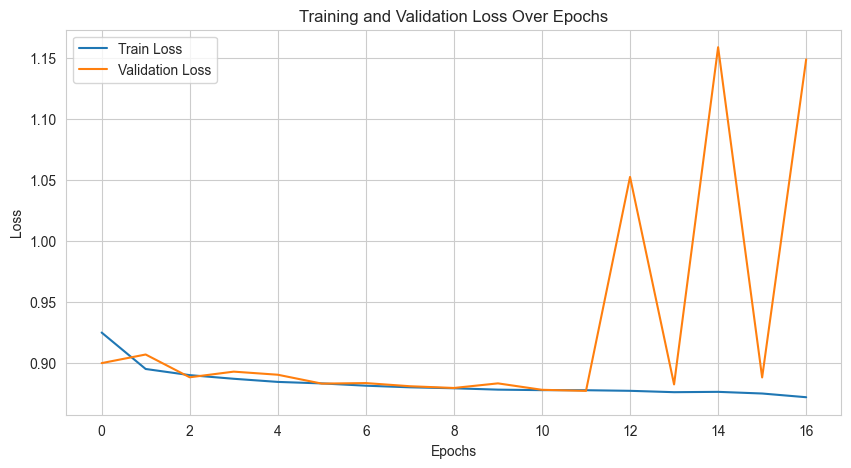

2025-06-22 23:44:11,545 - INFO - 🔬 최종 검증 데이터셋에 대한 평균 복원 오차: 1.149489
2025-06-22 23:44:11,545 - INFO - 🎉 모든 과정 완료!



📈 최종 결과 요약:
- 훈련 에포크: 17
- 최종 훈련 손실: 0.871759
- 최종 검증 손실: 1.148740
- 최종 복원 오차: 1.149489


In [7]:
def plot_training_history(history):
    """훈련 과정의 손실 곡선을 시각화"""
    plt.figure(figsize=(10, 5))
    plt.plot(history['train_loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Validation Loss')
    plt.title('Training and Validation Loss Over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

def analyze_reconstruction(model, dataloader, config: TrainingConfig):
    """복원 오차 분석"""
    model.eval()
    total_error = 0
    total_count = 0
    with torch.no_grad():
        for vectors, conditions, mask in dataloader:
            vectors, conditions, mask = vectors.to(config.device), conditions.to(config.device), mask.to(config.device)
            recon_x, _ = model(vectors, conditions)
            loss = composite_loss(recon_x, vectors, mask, config)
            total_error += loss.item() * vectors.size(0)
            total_count += vectors.size(0)
    
    avg_error = total_error / total_count
    logging.info(f"🔬 최종 검증 데이터셋에 대한 평균 복원 오차: {avg_error:.6f}")
    return avg_error

# --- 결과 분석 실행 ---
logging.info("📊 훈련 결과 시각화...")
plot_training_history(history)
final_error = analyze_reconstruction(trained_model, val_loader, config)

logging.info("🎉 모든 과정 완료!")
print(f"\n📈 최종 결과 요약:")
print(f"- 훈련 에포크: {len(history['train_loss'])}")
print(f"- 최종 훈련 손실: {history['train_loss'][-1]:.6f}")
print(f"- 최종 검증 손실: {history['val_loss'][-1]:.6f}")
print(f"- 최종 복원 오차: {final_error:.6f}")


2025-06-22 23:44:11,606 - INFO - 🔬 1000개 샘플에 대한 복원 성능 분석 시작...
2025-06-22 23:44:11,616 - INFO - 샘플 1: MSE=0.009324, RMSE=0.096559, MAE=0.078798, Cosine_Sim=0.997586
2025-06-22 23:44:11,617 - INFO - 샘플 2: MSE=1.037025, RMSE=1.018344, MAE=0.811057, Cosine_Sim=0.376180
2025-06-22 23:44:11,619 - INFO - 샘플 3: MSE=0.754615, RMSE=0.868686, MAE=0.696167, Cosine_Sim=0.408780
2025-06-22 23:44:11,620 - INFO - 샘플 4: MSE=0.622525, RMSE=0.789003, MAE=0.623328, Cosine_Sim=0.596079
2025-06-22 23:44:11,623 - INFO - 샘플 5: MSE=0.009684, RMSE=0.098406, MAE=0.073299, Cosine_Sim=0.995985
2025-06-22 23:44:11,623 - INFO - 샘플 6: MSE=0.952892, RMSE=0.976162, MAE=0.784766, Cosine_Sim=0.462356
2025-06-22 23:44:11,625 - INFO - 샘플 7: MSE=0.061521, RMSE=0.248035, MAE=0.224450, Cosine_Sim=0.998939
2025-06-22 23:44:11,627 - INFO - 샘플 8: MSE=0.628252, RMSE=0.792623, MAE=0.624960, Cosine_Sim=0.582591
2025-06-22 23:44:11,629 - INFO - 샘플 9: MSE=0.182752, RMSE=0.427495, MAE=0.300667, Cosine_Sim=0.937629
2025-06-22 23:44:11


📊 복원 성능 통계 요약 (1000개 샘플):
MSE:           평균=0.444370 ± 0.358757
RMSE:          평균=0.571978 ± 0.342361
MAE:           평균=0.454716 ± 0.273614
Cosine 유사도: 평균=0.693461 ± 0.260617


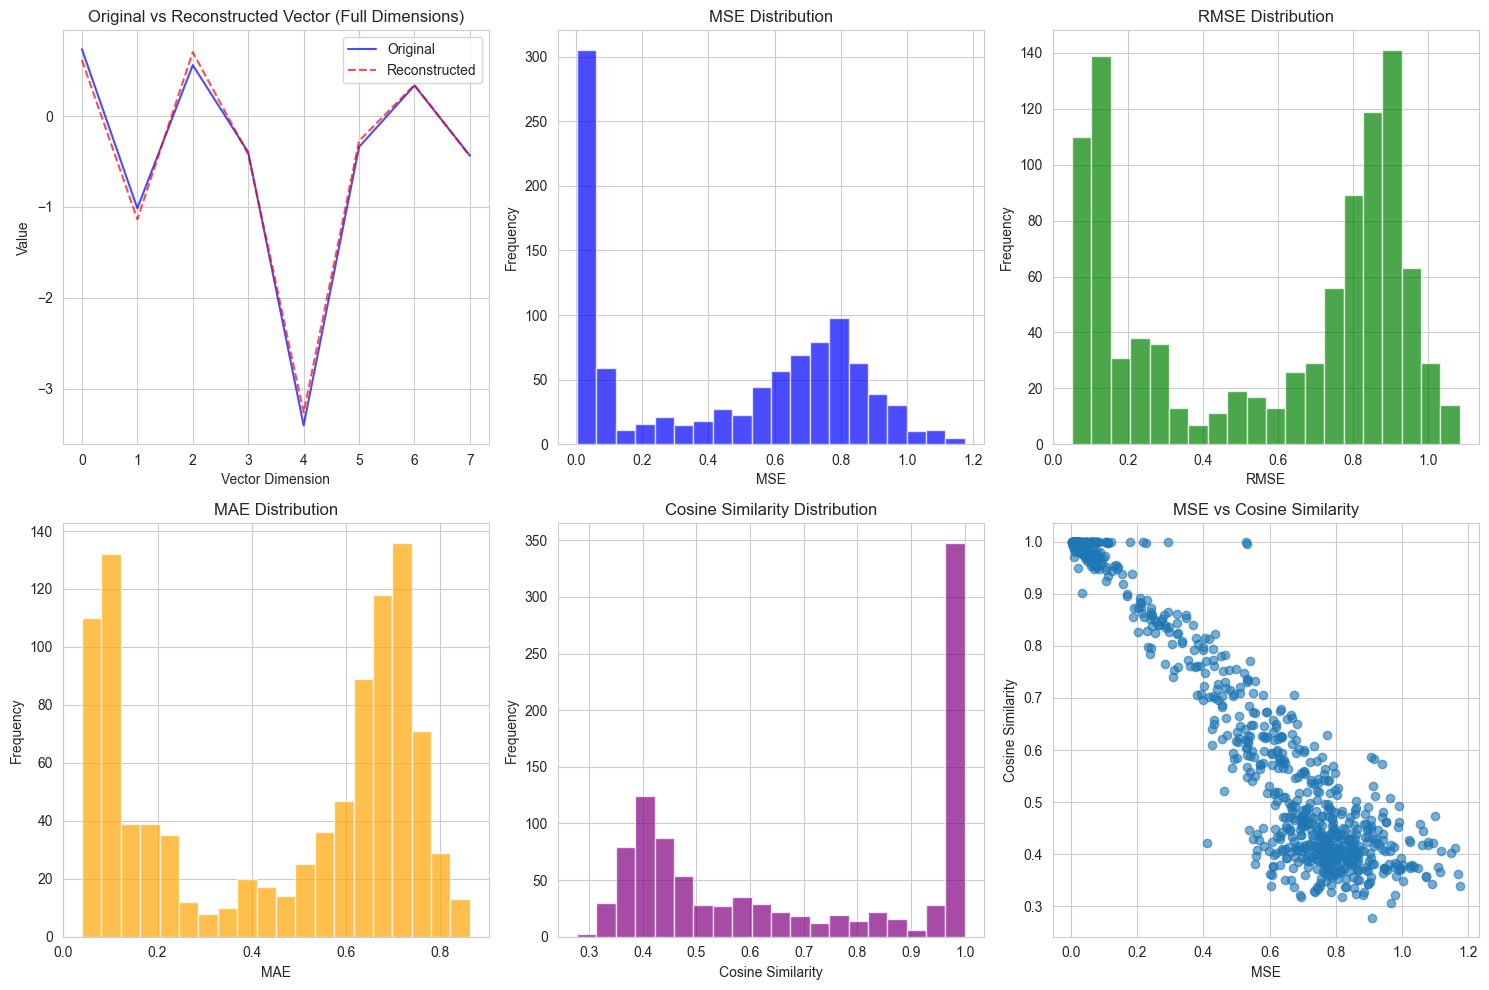

2025-06-22 23:44:14,298 - INFO - 🎯 실제 수치 비교 분석 완료!


In [8]:
import numpy as np
import torch
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy.spatial.distance import cosine
import matplotlib.pyplot as plt

def calculate_reconstruction_metrics(model, val_loader, config: TrainingConfig, num_samples=1000):
    """실제 벡터와 복원 벡터의 수치적 비교 분석"""
    model.eval()
    
    metrics_results = {
        'mse_scores': [],
        'rmse_scores': [],
        'mae_scores': [],
        'cosine_similarities': [],
        'original_vectors': [],
        'reconstructed_vectors': []
    }
    
    logging.info(f"🔬 {num_samples}개 샘플에 대한 복원 성능 분석 시작...")
    
    with torch.no_grad():
        sample_count = 0
        for vectors, conditions, mask in val_loader:
            if sample_count >= num_samples:
                break
                
            vectors = vectors.to(config.device)
            conditions = conditions.to(config.device)
            mask = mask.to(config.device)
            
            # 모델을 통한 복원
            recon_vectors, _ = model(vectors, conditions)
            
            # CPU로 이동하여 numpy 배열로 변환
            orig_np = vectors.cpu().numpy()
            recon_np = recon_vectors.cpu().numpy()
            mask_np = mask.cpu().numpy()
            
            # 각 샘플에 대해 메트릭 계산
            batch_size = orig_np.shape[0]
            for i in range(min(batch_size, num_samples - sample_count)):
                # 마스크가 적용된 부분만 비교
                valid_indices = mask_np[i] > 0
                
                if np.sum(valid_indices) > 0:  # 유효한 인덱스가 있는 경우만
                    orig_vec = orig_np[i][valid_indices]
                    recon_vec = recon_np[i][valid_indices]
                    
                    # 메트릭 계산
                    mse = mean_squared_error(orig_vec, recon_vec)
                    rmse = np.sqrt(mse)
                    mae = mean_absolute_error(orig_vec, recon_vec)
                    
                    # 코사인 유사도 (1 - 코사인 거리)
                    cosine_sim = 1 - cosine(orig_vec, recon_vec)
                    
                    # 결과 저장
                    metrics_results['mse_scores'].append(mse)
                    metrics_results['rmse_scores'].append(rmse)
                    metrics_results['mae_scores'].append(mae)
                    metrics_results['cosine_similarities'].append(cosine_sim)
                    metrics_results['original_vectors'].append(orig_vec)
                    metrics_results['reconstructed_vectors'].append(recon_vec)
                    
                    sample_count += 1
                    
                    # 상세 로그 출력
                    logging.info(f"샘플 {sample_count}: MSE={mse:.6f}, RMSE={rmse:.6f}, MAE={mae:.6f}, Cosine_Sim={cosine_sim:.6f}")
                    
                if sample_count >= num_samples:
                    break
    
    # 통계 요약
    mse_mean = np.mean(metrics_results['mse_scores'])
    mse_std = np.std(metrics_results['mse_scores'])
    rmse_mean = np.mean(metrics_results['rmse_scores'])
    rmse_std = np.std(metrics_results['rmse_scores'])
    mae_mean = np.mean(metrics_results['mae_scores'])
    mae_std = np.std(metrics_results['mae_scores'])
    cosine_mean = np.mean(metrics_results['cosine_similarities'])
    cosine_std = np.std(metrics_results['cosine_similarities'])
    
    # 결과 출력
    print(f"\n📊 복원 성능 통계 요약 ({sample_count}개 샘플):")
    print(f"{'='*50}")
    print(f"MSE:           평균={mse_mean:.6f} ± {mse_std:.6f}")
    print(f"RMSE:          평균={rmse_mean:.6f} ± {rmse_std:.6f}")
    print(f"MAE:           평균={mae_mean:.6f} ± {mae_std:.6f}")
    print(f"Cosine 유사도: 평균={cosine_mean:.6f} ± {cosine_std:.6f}")
    print(f"{'='*50}")
    
    # 시각화
    plt.figure(figsize=(15, 10))
    
    # 첫 번째 샘플의 원본 vs 복원 비교 (전체 차원)
    plt.subplot(2, 3, 1)
    if len(metrics_results['original_vectors']) > 0:
        orig_sample = metrics_results['original_vectors'][0]  # 전체 차원
        recon_sample = metrics_results['reconstructed_vectors'][0]
        plt.plot(orig_sample, 'b-', label='Original', alpha=0.7)
        plt.plot(recon_sample, 'r--', label='Reconstructed', alpha=0.7)
        plt.title('Original vs Reconstructed Vector (Full Dimensions)')
        plt.xlabel('Vector Dimension')
        plt.ylabel('Value')
        plt.legend()
        plt.grid(True)
    
    # MSE 분포
    plt.subplot(2, 3, 2)
    plt.hist(metrics_results['mse_scores'], bins=20, alpha=0.7, color='blue')
    plt.title('MSE Distribution')
    plt.xlabel('MSE')
    plt.ylabel('Frequency')
    plt.grid(True)
    
    # RMSE 분포
    plt.subplot(2, 3, 3)
    plt.hist(metrics_results['rmse_scores'], bins=20, alpha=0.7, color='green')
    plt.title('RMSE Distribution')
    plt.xlabel('RMSE')
    plt.ylabel('Frequency')
    plt.grid(True)
    
    # MAE 분포
    plt.subplot(2, 3, 4)
    plt.hist(metrics_results['mae_scores'], bins=20, alpha=0.7, color='orange')
    plt.title('MAE Distribution')
    plt.xlabel('MAE')
    plt.ylabel('Frequency')
    plt.grid(True)
    
    # 코사인 유사도 분포
    plt.subplot(2, 3, 5)
    plt.hist(metrics_results['cosine_similarities'], bins=20, alpha=0.7, color='purple')
    plt.title('Cosine Similarity Distribution')
    plt.xlabel('Cosine Similarity')
    plt.ylabel('Frequency')
    plt.grid(True)
    
    # 메트릭 간 상관관계
    plt.subplot(2, 3, 6)
    plt.scatter(metrics_results['mse_scores'], metrics_results['cosine_similarities'], alpha=0.6)
    plt.xlabel('MSE')
    plt.ylabel('Cosine Similarity')
    plt.title('MSE vs Cosine Similarity')
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()
    
    return metrics_results

# 실제 수치 비교 실행
reconstruction_metrics = calculate_reconstruction_metrics(trained_model, val_loader, config)

logging.info("🎯 실제 수치 비교 분석 완료!")
